## PART E — MINI PROJECT (Generative AI Insight)
## Mini Project: Diffusion-based Prompt Feature Generator
## Task 8: Prompt Feature Noising

In [1]:
import numpy as np

# Example prompts
prompts = [
    "Generate a short story",
    "Summarize this article",
    "Write a poem about AI"
]

# Simple numeric encoding: [length, word count, verb count, complexity score]
# (values are illustrative)
prompt_features = np.array([
    [10, 2, 1, 0.5],
    [12, 3, 2, 0.6],
    [8, 2, 1, 0.4]
])

print("Encoded prompt features:\n", prompt_features)

Encoded prompt features:
 [[10.   2.   1.   0.5]
 [12.   3.   2.   0.6]
 [ 8.   2.   1.   0.4]]


## Task 9: Train Prompt Denoiser

In [2]:
import numpy as np

# Original prompt features (clean)
prompt_features = np.array([
    [10, 2, 1, 0.5],
    [12, 3, 2, 0.6],
    [8, 2, 1, 0.4]
])

# Apply forward diffusion (noise)
def add_noise(x, beta=0.05):
    return x + np.random.randn(*x.shape) * beta

noisy_features = add_noise(prompt_features)
print("Noisy features:\n", noisy_features)

Noisy features:
 [[ 9.96544228  1.96221329  0.99727246  0.39549072]
 [12.08566003  3.02505584  2.08281477  0.68273571]
 [ 8.0408387   1.8956002   0.94131974  0.38218761]]


## Task 10: Generate New Prompt Features

In [3]:
import numpy as np

# Original prompt features
prompt_features = np.array([
    [10, 2, 1, 0.5],
    [12, 3, 2, 0.6],
    [8, 2, 1, 0.4]
])

feature_dim = prompt_features.shape[1]
num_samples = 5  # number of new prompts to generate
noise_dim = feature_dim

In [4]:
def forward_diffusion(x, T=5, beta=0.05):
    x_noisy = x.copy()
    diffusion_steps = [x_noisy.copy()]
    for t in range(T):
        noise = np.random.randn(*x.shape) * beta
        x_noisy += noise
        diffusion_steps.append(x_noisy.copy())
    return diffusion_steps

# Apply diffusion to real features (simulating training data)
diffused_steps = forward_diffusion(prompt_features, T=5)

In [5]:
def reverse_diffusion(T=5, beta=0.05, num_samples=5, feature_dim=4):
    # Start from random noise
    x = np.random.randn(num_samples, feature_dim)
    generated_steps = [x.copy()]
    
    # Iteratively denoise (simple simulation)
    for t in reversed(range(T)):
        # move slightly toward real feature mean (simulating learned denoiser)
        x = x - beta * (x - prompt_features.mean(axis=0))
        generated_steps.append(x.copy())
    return generated_steps

generated_steps = reverse_diffusion(T=5, num_samples=num_samples, feature_dim=feature_dim)
generated_features = generated_steps[-1]

print("Generated prompt features:\n", generated_features)
print("Real prompt features:\n", prompt_features)

Generated prompt features:
 [[ 1.4702827  -0.19567045  1.31861269  2.21378556]
 [ 2.22242398  1.17992152  0.29246158  0.05365013]
 [ 1.04768419 -0.17516045  0.39681725  0.4252599 ]
 [ 2.11742332  0.19505538 -0.87652212 -1.56391233]
 [ 1.33207024  1.13516894  0.9395887   0.45573657]]
Real prompt features:
 [[10.   2.   1.   0.5]
 [12.   3.   2.   0.6]
 [ 8.   2.   1.   0.4]]


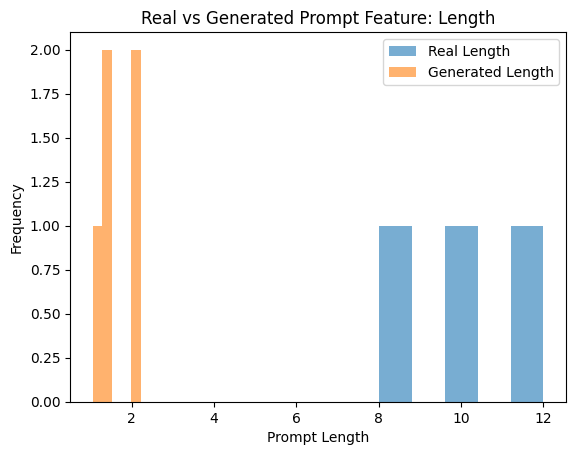

In [6]:
import matplotlib.pyplot as plt

# Compare first feature: length
plt.hist(prompt_features[:,0], bins=5, alpha=0.6, label='Real Length')
plt.hist(generated_features[:,0], bins=5, alpha=0.6, label='Generated Length')
plt.xlabel("Prompt Length")
plt.ylabel("Frequency")
plt.title("Real vs Generated Prompt Feature: Length")
plt.legend()
plt.show()